<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/practice/Student_TimeSeries_Forecasting_Example_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

과제 1(유근일) - 기존 양식 활용하여 작성하였습니다.

# AR(p) 모델 — 대기 중 CO₂ 농도 시계열 예측

- 데이터: **NOAA 마우나로아 관측소(Mauna Loa Observatory)** 월별 CO₂ 농도 (ppm)
- 출처: https://gml.noaa.gov/ccgg/trends/



# 시계열 예측방법
* 전체(Full series)
* 고정 원점(=정적 파라미터) 예측
* 롤링 윈도우(Rolling window)
* 확장 윈도우(Expanding window)

# 데이터 소개 — NOAA 마우나로아 CO₂

- **측정 대상**: 대기 중 이산화탄소 농도 (단위: ppm, parts per million)
- **기간**: 1958년 3월 ~ 현재 (월별 평균)
- **특징**: 장기 상승 추세 + 연간 계절 진동(봄 최고 / 가을 최저)
- **활용**: 기후 변화 연구의 핵심 지표 중 하나


                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  816
Model:                    AutoReg(13)   Log Likelihood                -311.892
Method:               Conditional MLE   S.D. of innovations              0.357
Date:                Tue, 24 Mar 2026   AIC                            653.784
Time:                        11:44:01   BIC                            724.109
Sample:                            13   HQIC                           680.795
                                  816                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0683      0.170     -6.293      0.000      -1.401      -0.736
y.L1           0.8812      0.033     26.957      0.000       0.817       0.945
y.L2          -0.0304      0.044     -0.698      0.4

/tmp/ipykernel_7136/3548962385.py:51: UserWarning: Glyph 45453 (\N{HANGUL SYLLABLE NONG}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout()
/tmp/ipykernel_7136/3548962385.py:51: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout()
/tmp/ipykernel_7136/3548962385.py:51: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout()
/tmp/ipykernel_7136/3548962385.py:51: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout()
/tmp/ipykernel_7136/3548962385.py:51: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout()
/tmp/ipykernel_7136/3548962385.py:51: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) m

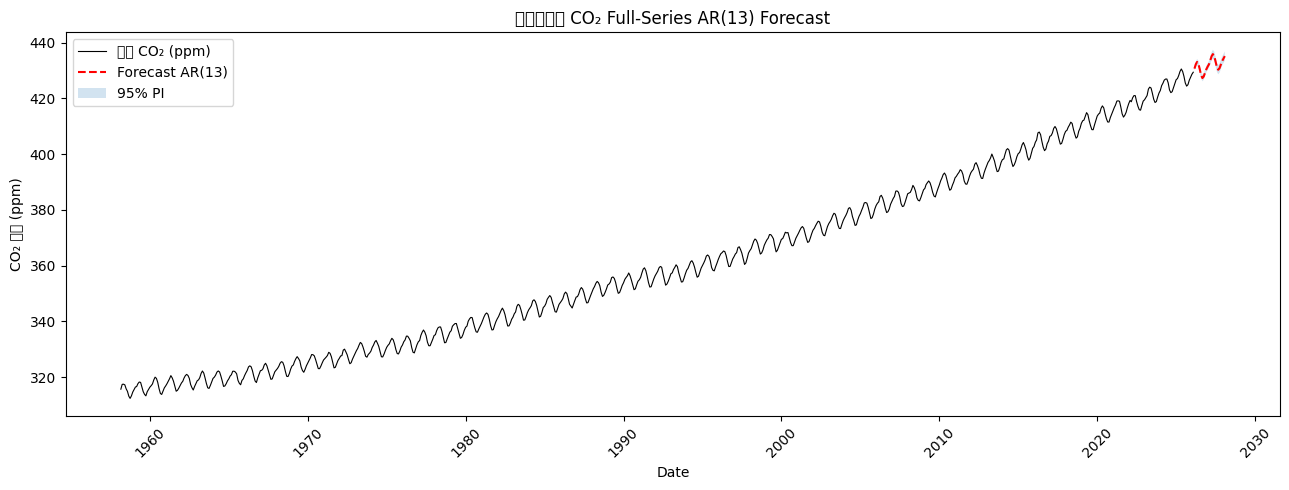


마지막 관측값: 429.35 ppm  (2026-02)
24개월 후 예측: 435.13 ppm


In [1]:
# Full-series AR(p) forecast (no refit, no holdout)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg

# 📌 1️⃣ 데이터 로드 — NOAA 마우나로아 월별 CO₂ 농도
CO2_URL = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv"

# Re-load data unconditionally to fix the corrupted state
df = pd.read_csv(
    CO2_URL, comment="#", header=None, skiprows=1,
    names=["year","month","decimal_date","average","deseasonalized","ndays","sdev","unc"]
)
# Convert 'average' column to numeric type, coercing errors to NaN
df["average"] = pd.to_numeric(df["average"], errors='coerce')
df = df[df["average"] > 0].copy()           # 결측(-99.99) 제거 및 NaN 제거
df["date"] = pd.to_datetime(df[["year","month"]].assign(day=1))
df = df.reset_index(drop=True)

y     = df["average"].to_numpy()
dates = df["date"].to_numpy()

# 📌 2️⃣ AR(p) 전체 구간 학습
p   = 13   # 월별 데이터 → 13차수(1년 주기 반영)
fit = AutoReg(y, lags=p, old_names=False).fit()
print(fit.summary())

# 📌 3️⃣ 미래 h 스텝 예측
h  = 24   # 앞으로 24개월(2년)
fc = np.asarray(fit.forecast(steps=h))
last_day = pd.to_datetime(dates[-1])
fc_dates = pd.date_range(last_day + pd.DateOffset(months=1), periods=h, freq="MS")

# 예측구간(confidence interval)
try:
    pred_res = fit.get_prediction(start=len(y), end=len(y) + h - 1)
    ci       = pred_res.conf_int(alpha=0.05)
    ci_lower, ci_upper = ci[:, 0], ci[:, 1]
except Exception:
    ci_lower = ci_upper = None

# 📌 4️⃣ 시각화
plt.figure(figsize=(13, 5))
plt.plot(dates, y, label="실제 CO₂ (ppm)", color="black", linewidth=0.8)
plt.plot(fc_dates, fc, label=f"Forecast AR({p})", linestyle="--", color="red")
if ci_lower is not None:
    plt.fill_between(fc_dates, ci_lower, ci_upper, alpha=0.2, label="95% PI")
plt.title(f"마우나로아 CO₂ Full-Series AR({p}) Forecast")
plt.xlabel("Date"); plt.ylabel("CO₂ 농도 (ppm)")
plt.xticks(rotation=45); plt.legend(); plt.tight_layout()
plt.show()

print(f"\n마지막 관측값: {y[-1]:.2f} ppm  ({pd.to_datetime(dates[-1]).strftime('%Y-%m')})")
print(f"24개월 후 예측: {fc[-1]:.2f} ppm")

### 🔎 출력 해석 포인트 (Full-series 예측 결과)
- CO₂ 농도는 장기 상승 추세 + 연간 계절 진동이 뚜렷합니다. AR(13)은 약 1년 주기를 어느 정도 반영합니다.
- 예측구간(PI)은 horizon이 길어질수록 넓어집니다.
- Full-series는 검증이 없으므로 '잘 맞아 보인다'는 사실만으로 일반화하면 위험합니다.


# 고정 원점(=정적 파라미터) 예측

첫 80%로 **한 번만 학습** → 그 파라미터로 **남은 전 구간을 재귀 예측**.


📌 Training MSE: 0.1178,  R²: 0.9998
📌 Test     MSE: 1.3600,  R²: 0.9870


/tmp/ipykernel_7136/3320697244.py:48: UserWarning: Glyph 45453 (\N{HANGUL SYLLABLE NONG}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_7136/3320697244.py:48: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_7136/3320697244.py:48: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_7136/3320697244.py:48: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_7136/3320697244.py:48: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_7136/332069

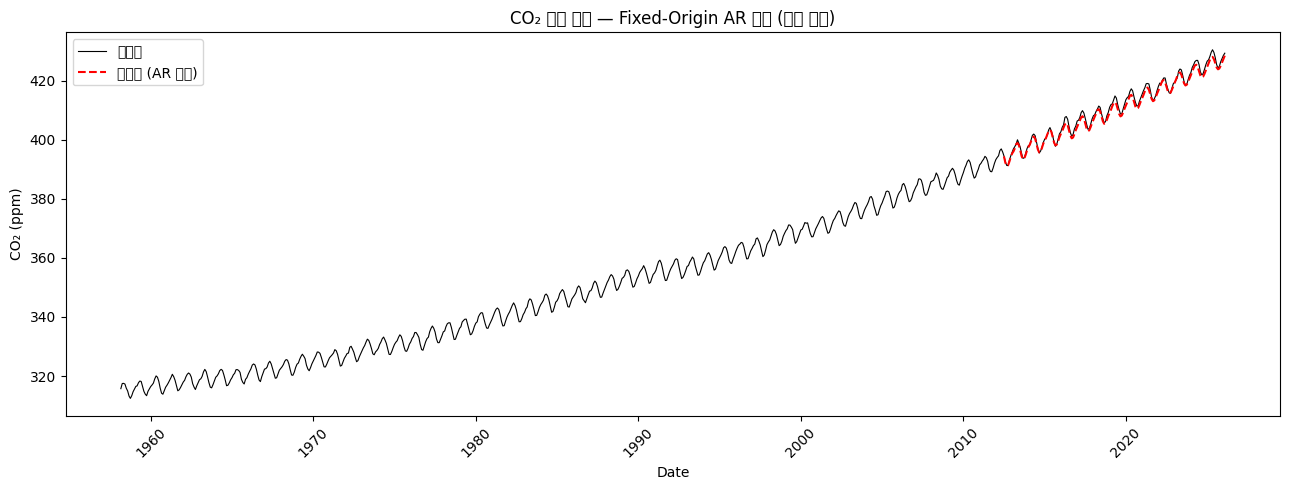

/tmp/ipykernel_7136/3320697244.py:56: UserWarning: Glyph 45453 (\N{HANGUL SYLLABLE NONG}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_7136/3320697244.py:56: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_7136/3320697244.py:56: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_7136/3320697244.py:56: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_7136/3320697244.py:56: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_7136/33206

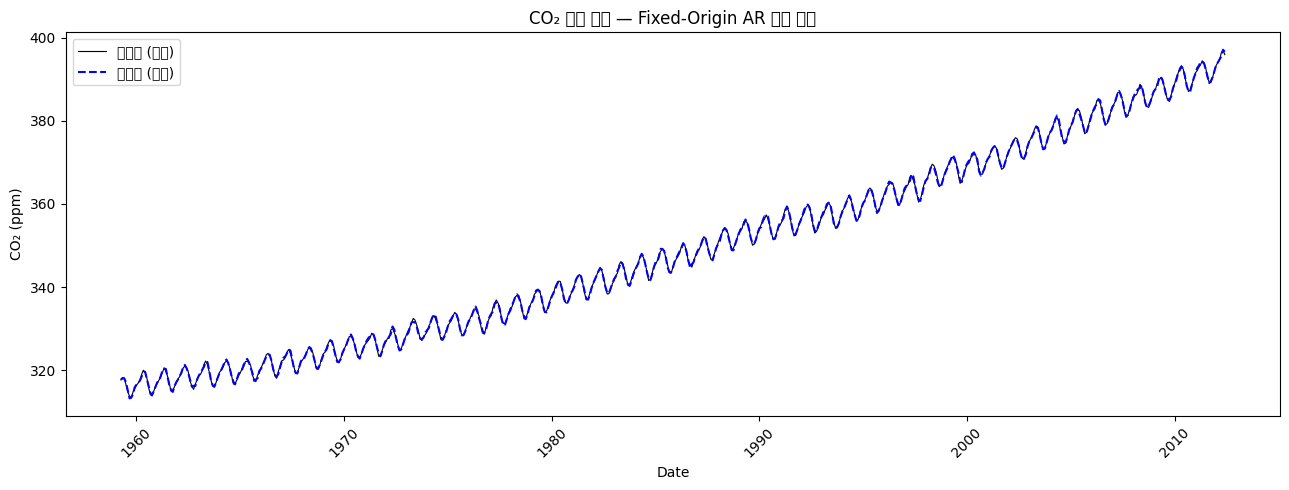

/tmp/ipykernel_7136/3320697244.py:64: UserWarning: Glyph 45453 (\N{HANGUL SYLLABLE NONG}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_7136/3320697244.py:64: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_7136/3320697244.py:64: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_7136/3320697244.py:64: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_7136/3320697244.py:64: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_7136/332069

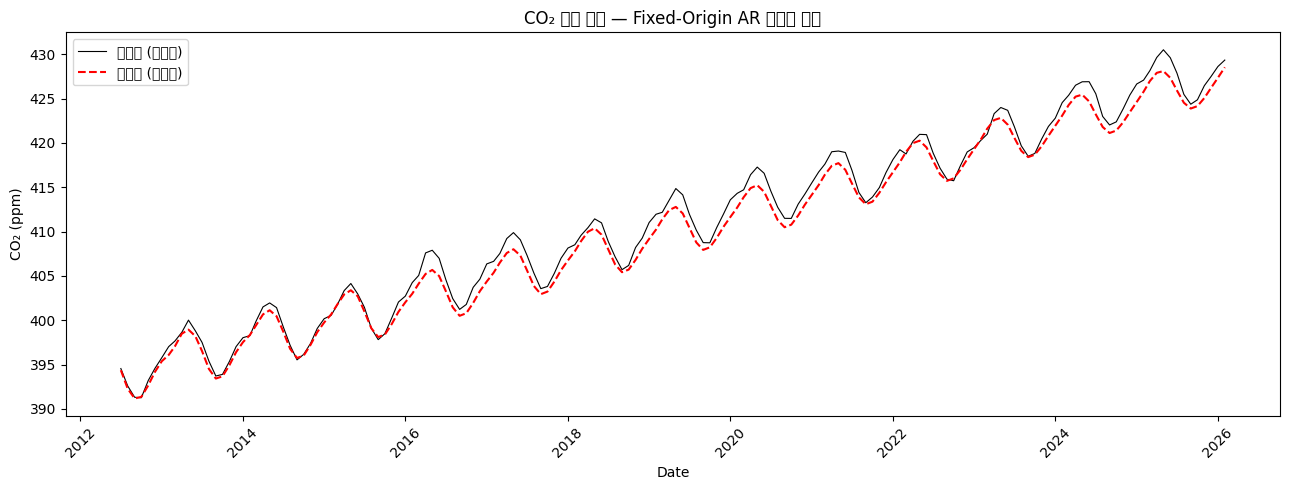

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error, r2_score

# 📌 1️⃣ 데이터 로드 (가드)
CO2_URL = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv"
if "df" not in globals():
    df = pd.read_csv(
        CO2_URL, comment="#", header=None,
        names=["year","month","decimal_date","average","deseasonalized","ndays","sdev","unc"]
    )
    df = df[df["average"] > 0].copy()
    df["date"] = pd.to_datetime(df[["year","month"]].assign(day=1))
    df = df.reset_index(drop=True)
else:
    df = df.copy()

# 📌 2️⃣ 학습/테스트 분할 (80/20)
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test  = df.iloc[train_size:]

# 📌 3️⃣ AR(p) 학습 (고정 원점)
lag = 13
model     = AutoReg(train["average"], lags=lag, old_names=False)
model_fit = model.fit()

# 📌 4️⃣ 예측
train_pred = model_fit.predict(start=lag, end=len(train) - 1)
test_pred  = model_fit.predict(start=len(train), end=len(df) - 1)

# 📌 5️⃣ 성능 평가
train_mse = mean_squared_error(train["average"][lag:], train_pred)
test_mse  = mean_squared_error(test["average"], test_pred)
train_r2  = r2_score(train["average"][lag:], train_pred)
test_r2   = r2_score(test["average"], test_pred)
print(f"📌 Training MSE: {train_mse:.4f},  R²: {train_r2:.4f}")
print(f"📌 Test     MSE: {test_mse:.4f},  R²: {test_r2:.4f}")

# 📌 6️⃣ 전체 시각화
plt.figure(figsize=(13, 5))
plt.plot(df["date"], df["average"], label="실제값", color="black", linewidth=0.8)
plt.plot(test["date"], test_pred, label="예측값 (AR 모델)", linestyle="--", color="red")
plt.title("CO₂ 농도 예측 — Fixed-Origin AR 모델 (전체 구간)")
plt.xlabel("Date"); plt.ylabel("CO₂ (ppm)")
plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

# 📌 7️⃣ 학습 구간 시각화
plt.figure(figsize=(13, 5))
plt.plot(train["date"][lag:], train["average"][lag:], label="실제값 (학습)", color="black", linewidth=0.8)
plt.plot(train["date"][lag:], train_pred, label="예측값 (학습)", color="blue", linestyle="--")
plt.title("CO₂ 농도 예측 — Fixed-Origin AR 학습 구간")
plt.xlabel("Date"); plt.ylabel("CO₂ (ppm)")
plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

# 📌 8️⃣ 테스트 구간 시각화
plt.figure(figsize=(13, 5))
plt.plot(test["date"], test["average"], label="실제값 (테스트)", color="black", linewidth=0.8)
plt.plot(test["date"], test_pred, label="예측값 (테스트)", color="red", linestyle="--")
plt.title("CO₂ 농도 예측 — Fixed-Origin AR 테스트 구간")
plt.xlabel("Date"); plt.ylabel("CO₂ (ppm)")
plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

### 🔎 출력 해석 포인트 (Fixed-origin 예측/평가)
- 학습 구간 예측(내삽)은 잘 맞지만, 테스트 구간(외삽)에서는 AR이 장기 추세를 잘 따라가지 못할 수 있습니다.
- CO₂처럼 **단조 상승 추세**가 있는 시계열에서는 R²가 왜곡될 수 있으므로 보조지표로 활용합니다.
- 세 번째 그래프(테스트 구간)가 두 번째(학습 구간)보다 다르게 보이는 것은 **고정 원점의 정상적인 한계**입니다.


# 롤링 윈도우(Rolling window)



> **학습목표 (롤링 윈도우(Rolling window) AR)**
>
- 워크-포워드(one-step-ahead) 예측을 수행한다.
- 윈도우 길이 W가 안정성(큰 W) vs 적응성(작은 W)에 미치는 영향을 설명한다.
- Rolling과 Expanding의 차이를 명확히 구분한다.

**해설(왜 Rolling이 중요한가?)**
- CO₂ 증가 속도는 시대에 따라 달라집니다(산업화 가속 등). Rolling은 최근 W개월만으로 재학습하여 이런 **구조 변화에 더 민감**하게 반응합니다.

[Rolling AR(13), W=120개월]  Test RMSE=0.4396, R²=0.9982


/tmp/ipykernel_7136/3486849388.py:50: UserWarning: Glyph 45453 (\N{HANGUL SYLLABLE NONG}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_7136/3486849388.py:50: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_7136/3486849388.py:50: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_7136/3486849388.py:50: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_7136/3486849388.py:50: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_7136/3486

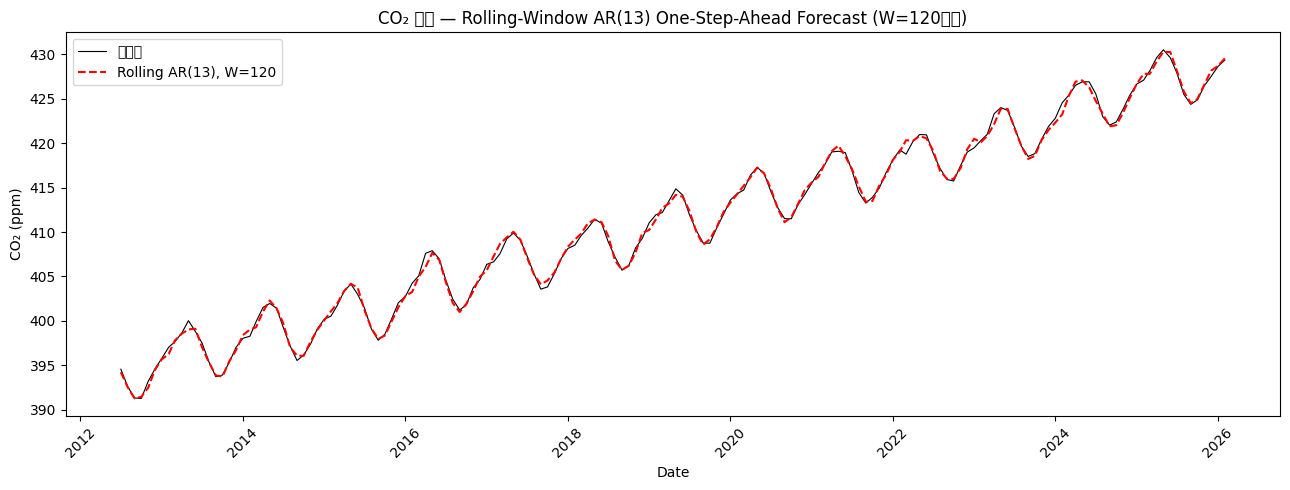

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error, r2_score

# 📌 (가드) 데이터 준비
CO2_URL = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv"
if "df" not in globals():
    df = pd.read_csv(
        CO2_URL, comment="#", header=None,
        names=["year","month","decimal_date","average","deseasonalized","ndays","sdev","unc"]
    )
    df = df[df["average"] > 0].copy()
    df["date"] = pd.to_datetime(df[["year","month"]].assign(day=1))
    df = df.reset_index(drop=True)

y          = df["average"].to_numpy()
dates      = df["date"].to_numpy()
train_size = int(len(y) * 0.8)

p     = 13    # AR 차수
W     = 120   # 롤링 윈도우 길이 (10년 = 120개월)
preds = []

for t in range(train_size, len(y)):
    start_idx = max(0, t - W)
    y_win = y[start_idx:t]
    if y_win.shape[0] <= p:
        preds.append(np.nan)
        continue
    fit  = AutoReg(y_win, lags=p, old_names=False).fit()
    yhat = float(np.asarray(fit.forecast(steps=1)).ravel()[0])
    preds.append(yhat)

actual = y[train_size:]
preds  = np.asarray(preds, dtype=float)
mask   = ~np.isnan(preds)

mse  = mean_squared_error(actual[mask], preds[mask])
rmse = np.sqrt(mse)
r2   = r2_score(actual[mask], preds[mask])
print(f"[Rolling AR({p}), W={W}개월]  Test RMSE={rmse:.4f}, R²={r2:.4f}")

plt.figure(figsize=(13, 5))
plt.plot(dates[train_size:], actual, label="실제값", color="black", linewidth=0.8)
plt.plot(dates[train_size:], preds, label=f"Rolling AR({p}), W={W}", linestyle="--", color="red")
plt.title(f"CO₂ 농도 — Rolling-Window AR({p}) One-Step-Ahead Forecast (W={W}개월)")
plt.xlabel("Date"); plt.ylabel("CO₂ (ppm)")
plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

### 🔎 출력 해석 포인트 (Rolling one-step 결과)
- 각 t에서 최근 W=120개월(10년)치만 사용해 재학습 → 1스텝 예측합니다.
- CO₂ 데이터는 추세가 완만하게 변하므로, W가 너무 작으면 추세 파악이 어렵고 W가 너무 크면 변화 반영이 느려집니다.
- NaN은 초반(윈도우가 p보다 작을 때) 발생하며, mask로 제외해 평가합니다.


> **학습목표 (확장 윈도우(Expanding window) AR)**
>
- 시작점부터 현재까지 모든 데이터를 사용해 반복 재학습하는 Expanding 예측을 수행한다.
- Expanding이 장기 안정성에는 유리할 수 있으나, 최근 구조 변화에는 둔감할 수 있음을 설명한다.
- Rolling vs Expanding의 선택 기준을 '구조 변화' 관점에서 제시한다.

[Expanding AR(13)]  Test RMSE=0.4109, R²=0.9984


/tmp/ipykernel_7136/4218957573.py:49: UserWarning: Glyph 45453 (\N{HANGUL SYLLABLE NONG}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_7136/4218957573.py:49: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_7136/4218957573.py:49: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_7136/4218957573.py:49: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_7136/4218957573.py:49: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()
/usr/local/lib/python3.12

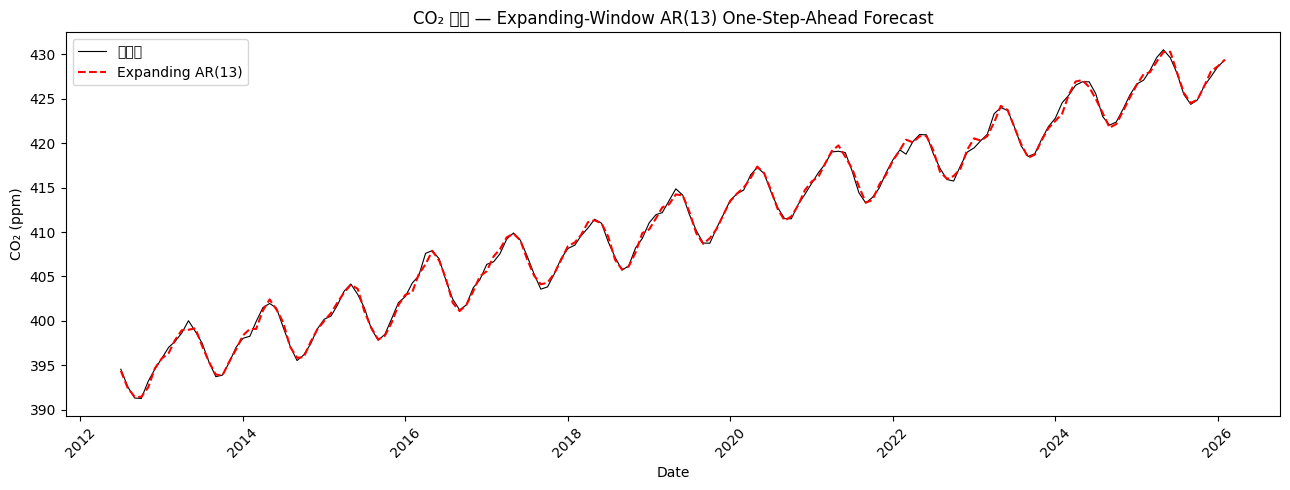

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error, r2_score

# 📌 (가드) 데이터 준비
CO2_URL = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv"
if "df" not in globals():
    df = pd.read_csv(
        CO2_URL, comment="#", header=None,
        names=["year","month","decimal_date","average","deseasonalized","ndays","sdev","unc"]
    )
    df = df[df["average"] > 0].copy()
    df["date"] = pd.to_datetime(df[["year","month"]].assign(day=1))
    df = df.reset_index(drop=True)
if "y" not in globals():
    y = df["average"].to_numpy()
if "train_size" not in globals():
    train_size = int(len(y) * 0.8)

p        = 13
preds_exp = []
actual   = y[train_size:]

for t in range(train_size, len(y)):
    y_win = y[:t]
    if y_win.shape[0] <= p:
        preds_exp.append(np.nan)
        continue
    fit  = AutoReg(y_win, lags=p, old_names=False).fit()
    yhat = float(np.asarray(fit.forecast(steps=1)).ravel()[0])
    preds_exp.append(yhat)

preds_exp = np.asarray(preds_exp, dtype=float)
mask      = ~np.isnan(preds_exp)

mse_exp  = mean_squared_error(actual[mask], preds_exp[mask])
rmse_exp = np.sqrt(mse_exp)
r2_exp   = r2_score(actual[mask], preds_exp[mask])
print(f"[Expanding AR({p})]  Test RMSE={rmse_exp:.4f}, R²={r2_exp:.4f}")

plt.figure(figsize=(13, 5))
plt.plot(df["date"].to_numpy()[train_size:], actual, label="실제값", color="black", linewidth=0.8)
plt.plot(df["date"].to_numpy()[train_size:], preds_exp,
         label=f"Expanding AR({p})", linestyle="--", color="red")
plt.title(f"CO₂ 농도 — Expanding-Window AR({p}) One-Step-Ahead Forecast")
plt.xlabel("Date"); plt.ylabel("CO₂ (ppm)")
plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

### 🔎 출력 해석 포인트 (Expanding one-step 결과)
- 각 t에서 1958년~t-1월까지 모두 사용하므로, 시간이 갈수록 학습 데이터가 증가합니다.
- CO₂ 데이터는 수십 년의 일관된 추세가 있어 Expanding이 유리할 수 있습니다.
- 구조 변화(예: CO₂ 증가 가속화)가 있으면 Rolling이 더 민감하게 반응합니다.



## ✅ 마무리 (요약 3줄)
1) **Full-series**는 개념 확인용이며, 검증이 없어 성능평가에는 부적절합니다.
2) **Fixed-origin**은 한 번 학습 후 테스트를 예측하는 가장 기본적인 OOS 평가입니다.
3) **Rolling/Expanding**은 운영 관점의 워크-포워드 평가로, CO₂처럼 추세가 변하는 데이터에서 차이가 크게 납니다.

## 📊 데이터 출처
- Keeling, C.D. et al. (2001), *NOAA/GML Mauna Loa CO₂ Record*  
  https://gml.noaa.gov/ccgg/trends/

